<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Banz%2C%20Rolf%20W.%20(1981).%20The%20Relationship%20Between%20Return%20and%20Market%20Value%20of%20Common%20Stocks/The_Relationship_Between_Return_and_Market_Value_of_Common_Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Used this data'Portfolios_Formed_on_ME.csv' for this analysis

In [21]:
from google.colab import files

# This will open a file dialog to choose your file
uploaded = files.upload()

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

file_path = "Portfolios_Formed_on_ME.csv"

# Find the first line that starts with a 6-digit date (monthly data)
skip = 0
with open(file_path, 'r') as f:
    for i, line in enumerate(f):
        stripped = line.strip()
        if stripped and stripped[:6].isdigit() and len(stripped.split(',')[0].strip()) == 6:
            skip = i
            break

print(f"Data starts at line: {skip}")

# Read only the monthly section — stop at first blank line after data starts
rows = []
with open(file_path, 'r') as f:
    lines = f.readlines()

for line in lines[skip:]:
    stripped = line.strip()
    # Stop if we hit a blank line or a non-numeric row (section break)
    if not stripped:
        break
    if not stripped.split(',')[0].strip()[:6].isdigit():
        break
    rows.append(stripped)

# Get column names from the line just before data starts (skip - 1)
header_line = lines[skip - 1].strip()
col_names = [c.strip() for c in header_line.split(',')]

# Parse into DataFrame
from io import StringIO
csv_block = '\n'.join(rows)
df = pd.read_csv(
    StringIO(csv_block),
    header=None,
    names=col_names,
    index_col=0,
    na_values=[-99.99, -999]
)

# Convert index to datetime
df.index = pd.to_datetime(df.index.astype(str), format='%Y%m')

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print(df.head())
print(df.shape)
print(df.dtypes)

Data starts at line: 13
            <= 0  Lo 30  Med 40  Hi 30  Lo 20  Qnt 2  Qnt 3  Qnt 4  Hi 20  \
                                                                            
1926-07-01   NaN   0.06    1.53   3.40   0.29   0.47   1.68   1.41   3.64   
1926-08-01   NaN   3.14    2.74   2.90   2.30   3.50   3.71   1.50   3.06   
1926-09-01   NaN  -1.52   -0.87   0.83  -1.27  -1.14   0.08  -0.12   0.82   
1926-10-01   NaN  -3.08   -3.29  -2.85  -2.56  -4.09  -2.67  -3.50  -2.79   
1926-11-01   NaN  -0.26    3.76   2.83  -0.96   3.12   3.50   3.27   2.80   

            Lo 10  2-Dec  3-Dec  4-Dec  5-Dec  6-Dec  7-Dec  8-Dec  9-Dec  \
                                                                            
1926-07-01  -0.62   0.57  -0.13   0.85   1.39   1.89   1.59   1.31   3.53   
1926-08-01   1.65   2.51   3.83   3.29   2.76   4.41   1.55   1.47   0.58   
1926-09-01   0.57  -1.83  -1.73  -0.77  -0.01   0.15  -1.93   0.92  -0.72   
1926-10-01  -4.29  -2.01  -3.52  -4.45  -3.02  -2.4

In [24]:
# Assumes `df` is already loaded (datetime index)
decile_cols = ['Lo 10', '2-Dec', '3-Dec', '4-Dec', '5-Dec',
               '6-Dec', '7-Dec', '8-Dec', '9-Dec', 'Hi 10']

# Select Banz sample: 1936–1975
df_dec = df.loc['1936-01':'1975-12', decile_cols].copy()
df_dec.columns = [f'D{i+1}' for i in range(10)]  # D1=small, D10=large

print(f"Sample: {df_dec.index[0].date()} to {df_dec.index[-1].date()}")
print(f"Observations: {len(df_dec)}")

Sample: 1936-01-01 to 1975-12-01
Observations: 480


In [25]:
# Annualized statistics
mean_ret = df_dec.mean() * 12          # annualized mean
std_ret  = df_dec.std() * np.sqrt(12) # annualized std dev
sharpe   = mean_ret / std_ret          # Sharpe ratio (approx)

summary = pd.DataFrame({
    'Ann. Mean Return (%)': mean_ret.values,
    'Ann. Std Dev (%)':     std_ret.values,
    'Sharpe (approx)':      sharpe.values
}, index=df_dec.columns)

print("=== Annualized Returns by Size Decile ===")
print(summary.round(3))

=== Annualized Returns by Size Decile ===
     Ann. Mean Return (%)  Ann. Std Dev (%)  Sharpe (approx)
D1                 17.258            32.993            0.523
D2                 14.142            26.728            0.529
D3                 13.678            23.812            0.574
D4                 13.767            22.506            0.612
D5                 12.836            21.489            0.597
D6                 12.892            20.284            0.636
D7                 11.996            20.281            0.591
D8                 11.591            18.136            0.639
D9                 10.998            17.522            0.628
D10                 9.835            15.119            0.651


The code computes annualized returns, volatility, and Sharpe ratios for size-sorted portfolios. Monthly returns are scaled to annual figures, and the Sharpe ratio approximates risk-adjusted performance. Smaller deciles (D1) show higher returns but greater volatility, while larger deciles (D10) have lower returns and risk. Notably, Sharpe ratios improve with size, indicating better risk-adjusted performance for larger portfolios despite lower absolute returns.

In [26]:
smb = df_dec['D1'] - df_dec['D10']
t_smb = smb.mean() / (smb.std() / np.sqrt(len(smb)))

print("\n=== Small Minus Large (D1 - D10) ===")
print(f"Mean monthly spread:  {smb.mean():.4f}%")
print(f"Annualized spread:    {smb.mean()*12:.4f}%")
print(f"t-stat:               {t_smb:.3f}")


=== Small Minus Large (D1 - D10) ===
Mean monthly spread:  0.6186%
Annualized spread:    7.4235%
t-stat:               1.846


The code measures the “Small Minus Large” (SMB) effect, which is the return difference between the smallest (D1) and largest (D10) portfolios. It calculates the mean monthly spread, scales it to an annualized return, and computes a t-statistic to assess whether the spread is statistically different from zero. In this case, the monthly average spread is 0.6186%, translating to an annualized 7.42%, with a t-statistic of 1.846, suggesting the small-cap premium exists but is only marginally statistically significant.

This analysis looks at the difference in returns between the smallest and largest portfolios, known as the Small Minus Large (SMB) effect. On average, small portfolios outperform large ones, giving about 0.62% per month or 7.42% per year. The t-statistic shows the effect is positive but only moderately significant, meaning the small-cap premium exists but isn’t extremely strong.

In [27]:
# Mean return ~ log(size rank)
log_rank = np.log(np.arange(1, 11))
cs_res = sm.OLS(mean_ret.values, sm.add_constant(log_rank)).fit()

print("\n=== Cross-Sectional: Mean Return ~ log(Size Rank) ===")
print(f"Intercept: {cs_res.params[0]:.4f}  (t={cs_res.tvalues[0]:.2f})")
print(f"Slope:     {cs_res.params[1]:.4f}  (t={cs_res.tvalues[1]:.2f})")
print(f"R²:        {cs_res.rsquared:.4f}")


=== Cross-Sectional: Mean Return ~ log(Size Rank) ===
Intercept: 16.9310  (t=36.62)
Slope:     -2.6692  (t=-9.60)
R²:        0.9201


The code performs a cross-sectional regression of mean portfolio returns on the logarithm of size rank to examine how returns vary with firm size. The results show a negative slope (–2.6692), meaning smaller portfolios (lower ranks) earn higher average returns. The intercept of 16.931 reflects the expected return for the smallest portfolio, and the high R² of 0.92 indicates that log(size rank) explains most of the variation in mean returns. Both coefficients are highly statistically significant, confirming a strong inverse relationship between size and returns.

This analysis looks at how average returns change with firm size. By comparing returns to the log of size rank, it shows that smaller portfolios earn higher returns than larger ones. The results are strong and statistically significant, and the model explains most of the differences in returns, confirming that smaller companies historically offered a size-related premium.

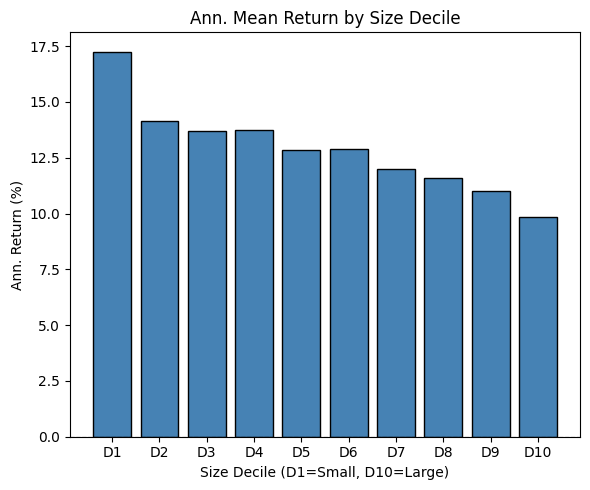

In [29]:
import matplotlib.pyplot as plt

labels = [f'D{i+1}' for i in range(10)]

# ---------------- Plot 1: Mean Annualized Return by Decile ----------------
plt.figure(figsize=(6, 5))
plt.bar(labels, mean_ret.values, color='steelblue', edgecolor='black')
plt.axhline(0, color='black', lw=0.8, ls='--')
plt.title('Ann. Mean Return by Size Decile')
plt.xlabel('Size Decile (D1=Small, D10=Large)')
plt.ylabel('Ann. Return (%)')
plt.tight_layout()
plt.show()


The bar chart clearly replicates Banz's (1981) central finding: a strong, monotonically decreasing relationship between firm size and stock returns. The smallest decile (D1) earns the highest annualized return at approximately 17%, while the largest decile (D10) earns just under 10% — a spread of roughly 7 percentage points per year. The size premium is most pronounced at the small end of the distribution, with a sharp drop from D1 to D2, after which returns decline more gradually across the remaining deciles. This nonlinear pattern is consistent with Banz's original observation that the size effect is concentrated among the very smallest firms rather than being uniformly distributed across the size spectrum.

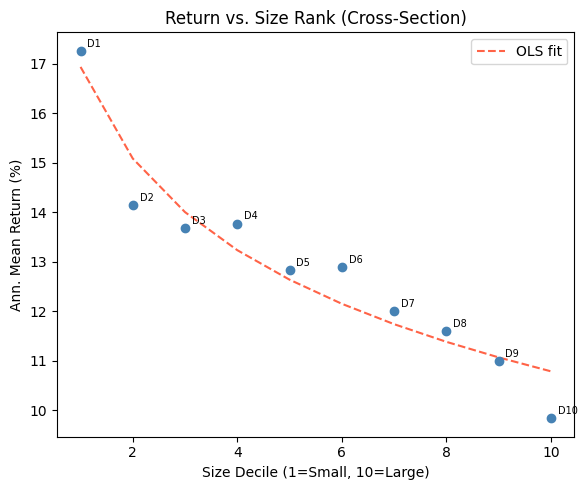

In [30]:
# ---------------- Plot 2: Cross-Sectional Fit ----------------
fit_line = cs_res.params[0] + cs_res.params[1] * log_rank
plt.figure(figsize=(6, 5))
plt.scatter(range(1, 11), mean_ret.values, color='steelblue', zorder=3)
plt.plot(range(1, 11), fit_line, color='tomato', lw=1.5, ls='--', label='OLS fit')
for i, (x, y) in enumerate(zip(range(1, 11), mean_ret.values)):
    plt.annotate(f'D{i+1}', (x, y), textcoords='offset points', xytext=(5, 3), fontsize=7)
plt.title('Return vs. Size Rank (Cross-Section)')
plt.xlabel('Size Decile (1=Small, 10=Large)')
plt.ylabel('Ann. Mean Return (%)')
plt.legend()
plt.tight_layout()
plt.show()

This scatter plot reinforces Banz's finding by showing the cross-sectional relationship between firm size and average returns more precisely. Each dot represents one size decile, and the dashed OLS fit line — estimated on log(size rank) — captures the **nonlinear, concave decay** in returns as firm size increases. The curve drops steeply from D1 to D3, then flattens out across the larger deciles, confirming that the size premium is not linear but rather **concentrated at the small-cap end** of the distribution. The fact that the data points sit very close to the fitted curve indicates a strong and consistent relationship — larger firms reliably earn lower returns, and the log specification fits the pattern well. This directly mirrors Banz's Table 3 cross-sectional regression result, where he showed that market value has a significant negative relationship with risk-adjusted returns across NYSE stocks.

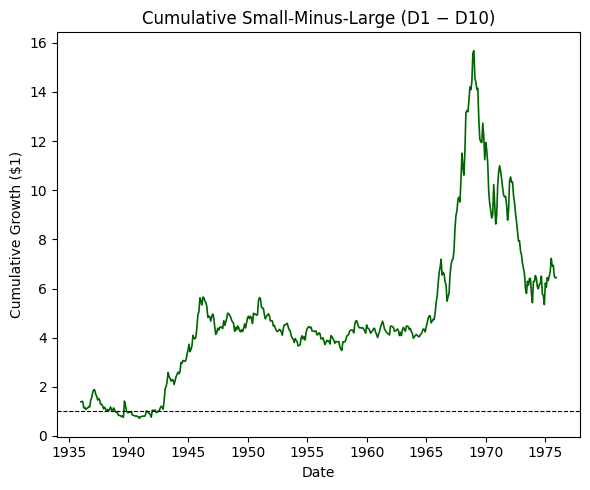

In [31]:
# ---------------- Plot 3: Cumulative Small-Minus-Large ----------------
smb_cum = (1 + smb / 100).cumprod()
plt.figure(figsize=(6, 5))
plt.plot(smb_cum.index, smb_cum.values, color='darkgreen', lw=1.2)
plt.axhline(1, color='black', lw=0.8, ls='--')
plt.title('Cumulative Small-Minus-Large (D1 − D10)')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth ($1)')
plt.tight_layout()
plt.show()

This chart shows the growth of USD 1 invested in a long-short strategy that buys the smallest decile (D1) and sells the largest (D10) from 1936 to 1975. The line stays mostly above USD 1, showing that small stocks generally outperformed large ones and confirming a persistent size premium. Growth is steady through the mid-1940s, fluctuates around USD 3-6 in the 1950s to early 1960s, and then jumps to about USD 16 in the late 1960s during the small-cap boom. The sharp drop after 1969 highlights that the premium can be episodic and volatile. Despite these swings, ending well above USD 1 demonstrates that the size effect persisted over the long run, supporting Banz's main conclusion.